<a href="https://colab.research.google.com/github/helaena-lianne/goat-weight/blob/main/mobilenetv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## code

In [ ]:
!pip install tensorflow

In [ ]:
import cv2
import keras
import pydot
import graphviz
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import os, json, random
import tensorflow as tf
from keras.models import Model
from keras import backend as K
import matplotlib.pyplot as plt
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, BatchNormalization

In [1]:
dataset_path = "/content/drive/MyDrive/segmentation/images/"
json_file  = "/content/drive/MyDrive/segmentation/weights.json"

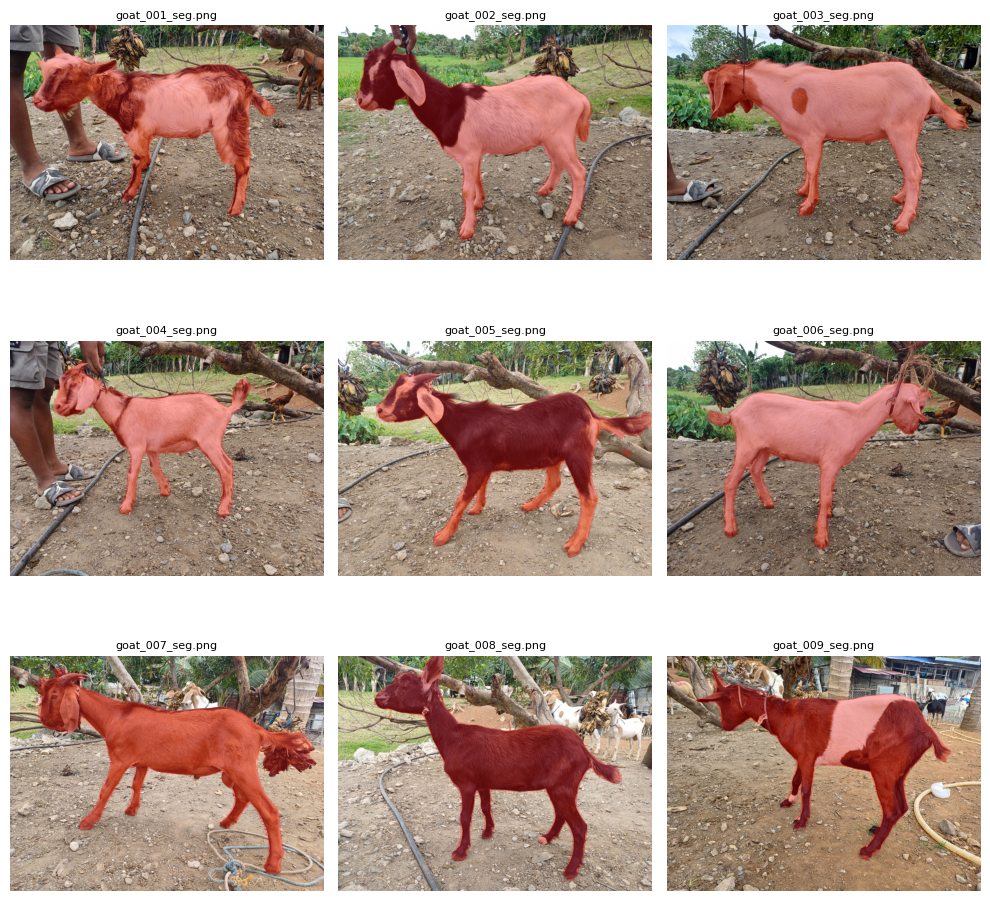

In [4]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

image_files = sorted(os.listdir(dataset_path))

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for ax, img_name in zip(axes.ravel(), image_files[:9]):
    img_path = os.path.join(dataset_path, img_name)
    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(img_name, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
with open(json_file, "r") as f:
    labels = json.load(f)

image_paths = [os.path.join(dataset_path, entry["filename"]) for entry in labels]
weights = [entry["weight"] for entry in labels]

img_size = (224, 224)

In [ ]:
# Preprocessing + Augmentations
rot_layer = tf.keras.layers.RandomRotation(factor=0.05, fill_mode="reflect")

# Translation + Zoom
trans_layer = tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1, fill_mode="reflect")
zoom_layer = tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1, fill_mode="reflect")

# Custom shear implementation (2D projective transform)
def random_shear(img, max_shear=0.2):
    shear_x = tf.random.uniform([], -max_shear, max_shear)
    shear_y = tf.random.uniform([], -max_shear, max_shear)

    transform = [1.0, shear_x, 0.0,
                 shear_y, 1.0, 0.0,
                 0.0,    0.0]  # projective transform
    transform = tf.convert_to_tensor(transform, dtype=tf.float32)

    img = tf.expand_dims(img, 0)
    img = tf.raw_ops.ImageProjectiveTransformV3(
        images=img,
        transforms=[transform],
        output_shape=tf.shape(img)[1:3],
        fill_mode="REFLECT",
        fill_value=0.0,
        interpolation="BILINEAR"
    )
    return img[0]

def preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size) / 255.0
    return img, label

def augment_image(img, label):
    # 1. Random flip (horizontal only)
    img = tf.image.random_flip_left_right(img)

    # 2. Random blur (via avg pooling)
    if tf.random.uniform(()) > 0.5:
        img = tf.nn.avg_pool2d(
            tf.expand_dims(img, 0),
            ksize=3, strides=1, padding="SAME"
        )[0]

    # 3. Random rotation
    img = rot_layer(img)

    # 4. Perspective warp (simulated with central crop + resize)
    if tf.random.uniform(()) > 0.5:
        crop = tf.image.central_crop(img, central_fraction=0.9)
        img = tf.image.resize(crop, img_size)

    # 5. Random translation
    img = trans_layer(img)

    # 6. Random zoom
    img = zoom_layer(img)

    # 7. Random shear (custom)
    if tf.random.uniform(()) > 0.5:
        img = random_shear(img)

    return img, label


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    image_paths, weights, train_size=0.8, random_state=20
)

max_weight = max(y_train)

y_train = [w / max_weight for w in y_train]
y_val   = [w / max_weight for w in y_val]

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(100)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)


In [ ]:
learning_rate = 0.0006745251544536569
dropout_rate = 0.06082340701586978
dense_unit1 = 128
dense_unit2 = 128
l2_reg = 1.8306567333408138e-06

# custom R² metric
def r_squared(y_true, y_pred):
    residual = tf.reduce_sum(tf.square(y_true - y_pred))
    total = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    r2 = 1 - residual / (total + tf.keras.backend.epsilon())
    return r2

r_squared.__name__ = "r_squared"

# model
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3),
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

model = base_model.output
model = GlobalAveragePooling2D()(model)
model = Dense(dense_unit1, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(model)
model = Dropout(dropout_rate)(model)
model = Dense(dense_unit2, activation='relu')(model)
model = Dropout(dropout_rate)(model)
output = Dense(1, activation='linear')(model)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=['mae', 'mape', r_squared]
)

earlystop_cb = EarlyStopping(
    monitor='val_loss',       # Watch validation loss
    patience=5,              # Stop after 10 epochs with no improvement
    restore_best_weights=True # Load best model weights automatically
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    verbose=1,
    callbacks=[earlystop_cb]
)

model.save("final_best_model.keras")


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 86s 10s/step - loss: 0.9298 - mae: 0.7841 - mape: 209.5057 - r_squared: -265.9896 - val_loss: 0.2850 - val_mae: 0.4113 - val_mape: 131.7626 - val_r_squared: -115.6421
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - loss: 0.3837 - mae: 0.5051 - mape: 146.6356 - r_squared: -105.9429 - val_loss: 0.0651 - val_mae: 0.2155 - val_mape: 65.1643 - val_r_squared: -31.4663
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 836ms/step - loss: 0.1021 - mae: 0.2505 - mape: 54.0686 - r_squared: -38.3568 - val_loss: 0.0408 - val_mae: 0.1649 - val_mape: 42.5014 - val_r_squared: -24.9800
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 801ms/step - loss: 0.1039 - mae: 0.2415 - mape: 47.5931 - r_squared: -32.1287 - val_loss: 0.0636 - val_mae: 0.2149 - val_mape: 64.9492 - val_r_squared: -36.8057
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 878ms/step - loss: 0.1181 - mae: 0.2705 - mape: 67.4642 - r_squared: -58.0293 - val_loss: 0.0722 - val_mae: 0.2321 - val_mape: 69.6735 - val_r_squared

In [ ]:
from google.colab import files
files.download("final_best_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --- Denormalize for actual (kg) interpretation ---
# Extract ground truth labels
y_true = []
for _, labels in val_ds.unbatch():
    y_true.append(labels.numpy())
y_true = np.array(y_true) * max_weight  # back to kg

# Predictions
y_pred = model.predict(val_ds).flatten() * max_weight  # back to kg

# Compute denormalized metrics
mse = np.mean((y_true - y_pred) ** 2)
mae = np.mean(np.abs(y_true - y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
ss_res = np.sum(np.square(y_true - y_pred))
ss_tot = np.sum(np.square(y_true - np.mean(y_true)))
r2_score = 1 - (ss_res / (ss_tot + 1e-10))

print("\n=== Denormalized Metrics (kg) ===")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f} kg")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2_score:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

=== Denormalized Metrics (kg) ===
MSE: 117.03
MAE: 8.79 kg
MAPE: 42.24%
R²: -0.2929


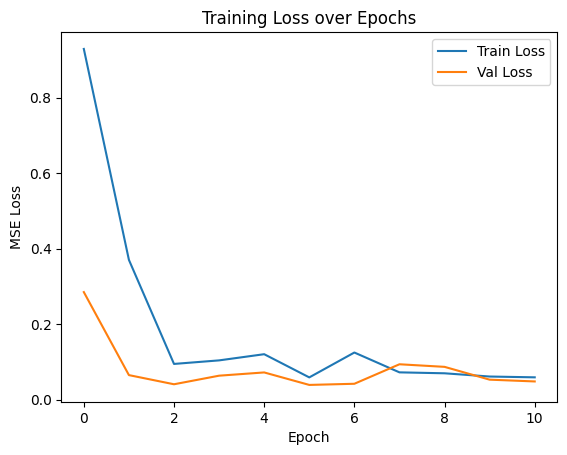

In [ ]:
history_dict = history.history

plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# === 1️⃣ Define custom R² metric ===
def r_squared(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())

r_squared.__name__ = "r_squared"

# === 2️⃣ Load your saved model ===
model = keras.models.load_model(
    "/content/final_best_model (2).keras",
    custom_objects={"r_squared": r_squared}
)

# === 3️⃣ Evaluate before fine-tuning ===
results = model.evaluate(val_ds, verbose=1)
metric_names = model.metrics_names
metrics_dict = dict(zip(metric_names, results))

print("\n=== Evaluation (Before Fine-tuning) ===")
for name, val in metrics_dict.items():
    print(f"{name}: {val:.4f}")

# === 4️⃣ Unfreeze part of MobileNetV2 for fine-tuning ===
base_model = model.layers[0]  # typically the feature extractor
base_model.trainable = True

fine_tune_at = 100  # unfreeze from this layer onward
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="mse",
    metrics=["mae", "mape", r_squared]
)

# === 5️⃣ Fine-tune ===
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    ]
)

# === 6️⃣ Evaluate after fine-tuning ===
results_ft = model.evaluate(val_ds, verbose=1)
metric_names = model.metrics_names
metrics_dict_ft = dict(zip(metric_names, results_ft))

print("\n=== Evaluation (After Fine-tuning) ===")
for name, val in metrics_dict_ft.items():
    print(f"{name}: {val:.4f}")

# === 7️⃣ Plot Loss and Metrics ===
plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

# MAE plot
plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

# R² plot (if available)
r2_key = [k for k in history.history.keys() if "r_squared" in k]
if r2_key:
    plt.subplot(1, 3, 3)
    plt.plot(history.history[r2_key[0]], label='Train R²')
    plt.plot(history.history["val_" + r2_key[0]], label='Val R²')
    plt.title('R² over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('R²')
    plt.legend()

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - loss: 0.0119 - mae: 0.0782 - mape: 18.6142

=== Evaluation (Before Fine-tuning) ===
loss: 0.0119
compile_metrics: 0.0782


AttributeError: 'InputLayer' object has no attribute 'layers'

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model

MAX_WEIGHT_KG = 55.0
IMAGE_SIZE = (224, 224)

def preprocess_new_image(path):
    """Loads, decodes, resizes, and normalizes a single image."""
    try:
        # Read the image file
        img = tf.io.read_file(path)
        # Decode to 3 channels (RGB)
        img = tf.image.decode_jpeg(img, channels=3)
        # Resize to the model's expected input size
        img = tf.image.resize(img, IMAGE_SIZE)
        # Normalize pixel values (0-255) to (0-1)
        img = img / 255.0
        # Add a batch dimension: (224, 224, 3) -> (1, 224, 224, 3)
        img = tf.expand_dims(img, axis=0)
        return img
    except Exception as e:
        print(f"Error processing image {path}: {e}")
        return None

def r_squared(y_true, y_pred):
    """Custom R² metric placeholder (required for loading the model)."""
    residual = tf.reduce_sum(tf.square(y_true - y_pred))
    total = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    r2 = 1 - residual / (total + tf.keras.backend.epsilon())
    return r2

try:
    model = load_model(
        "/content/final_best_model.keras",
        custom_objects={'r_squared': r_squared}
    )
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Ensure 'final_best_model.keras' is in the current directory and MAX_WEIGHT_KG is correct.")
    exit()

# --- 3. Prediction Function ---

def predict_goat_weight(image_path):
    """Predicts the goat's weight from an image path."""

    # 1. Preprocess
    input_tensor = preprocess_new_image(image_path)
    if input_tensor is None:
        return None

    # 2. Make the prediction (output is normalized, 0-1)
    normalized_prediction = model.predict(input_tensor)[0][0]

    # 3. Denormalize the result
    predicted_weight_kg = normalized_prediction * MAX_WEIGHT_KG

    # Ensure weight is not negative
    predicted_weight_kg = max(0.0, predicted_weight_kg)

    return predicted_weight_kg

# --- 4. Example Usage ---

# Define the path to the image you want to test
new_image_path = "/content/Screenshot 2025-10-18 181305.png"

# Run the prediction
predicted_weight = predict_goat_weight(new_image_path)

if predicted_weight is not None:
    print("\n-------------------------------------------")
    print(f"Image: {new_image_path}")
    print(f"Predicted Goat Weight: {predicted_weight:.2f} kg")
    print("-------------------------------------------")

Model loaded successfully.


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

-------------------------------------------
Image: /content/Screenshot 2025-10-18 181305.png
Predicted Goat Weight: 16.19 kg
-------------------------------------------


=== Paired t-test Results ===
     t-statistic   p-value
MSE    -5.037573  0.000702
MAE    -6.723718  0.000086
R²      2.662864  0.025924

Interpretation:
MSE: Significant difference (p = 0.0007)
MAE: Significant difference (p = 0.0001)
R²: Significant difference (p = 0.0259)


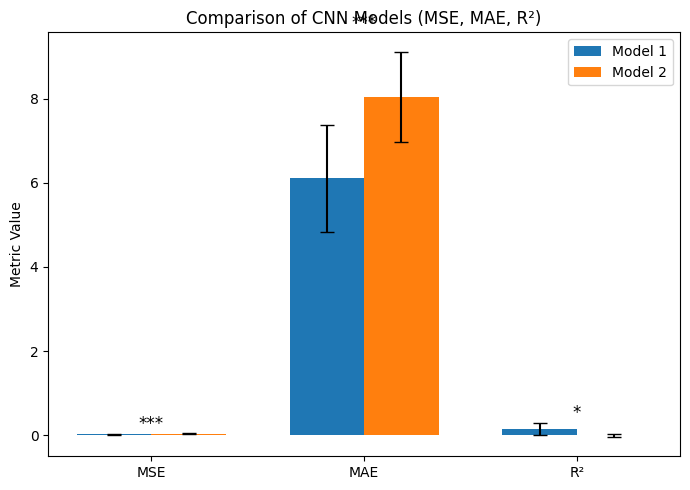

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# === 1️⃣ Input your data ===
# Model 1 metrics
mse_model1 = [0.0191, 0.0414, 0.016, 0.0119, 0.0191, 0.0165, 0.0201, 0.0372, 0.0169, 0.0198]
mae_model1 = [6.73, 8.52, 4.48, 4.3, 6.21, 4.94, 6.91, 7.4, 5.66, 5.89]
r2_model1  = [0.0539, 0.0499, 0.0875, 0.0881, 0.0582, 0.0812, 0.0531, 0.0673, 0.459, 0.412]

# Model 2 metrics
mse_model2 = [0.0431, 0.049, 0.0389, 0.0313, 0.0322, 0.0298, 0.0333, 0.0319, 0.032, 0.0302]
mae_model2 = [9.82, 10.29, 7.57, 7.39, 7.33, 6.99, 8.06,  7.99, 7.01, 8.01]
r2_model2  = [0.078847, -0.0499, -0.0642, 0.03868, 0.01243, 0.009546, -0.009671, -0.003622, -0.006759, -0.041012]

# === 2️⃣ Perform paired t-tests ===
metrics = ["MSE", "MAE", "R²"]
model1_data = [mse_model1, mae_model1, r2_model1]
model2_data = [mse_model2, mae_model2, r2_model2]

results = {}
for metric, data1, data2 in zip(metrics, model1_data, model2_data):
    t_stat, p_value = stats.ttest_rel(data1, data2)
    results[metric] = {"t-statistic": t_stat, "p-value": p_value}

# Convert results to DataFrame for clarity
df = pd.DataFrame(results).T
print("=== Paired t-test Results ===")
print(df)
print("\nInterpretation:")
for metric, row in df.iterrows():
    if row["p-value"] < 0.05:
        print(f"{metric}: Significant difference (p = {row['p-value']:.4f})")
    else:
        print(f"{metric}: No significant difference (p = {row['p-value']:.4f})")

# === 3️⃣ Plot bar chart with significance ===
# Compute mean and standard deviation for both models
means1 = [np.mean(d) for d in model1_data]
means2 = [np.mean(d) for d in model2_data]
stds1 = [np.std(d) for d in model1_data]
stds2 = [np.std(d) for d in model2_data]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, means1, width, yerr=stds1, capsize=5, label='Model 1')
bars2 = ax.bar(x + width/2, means2, width, yerr=stds2, capsize=5, label='Model 2')

ax.set_ylabel('Metric Value')
ax.set_title('Comparison of CNN Models (MSE, MAE, R²)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Add significance stars based on p-value
for i, metric in enumerate(metrics):
    p = df.loc[metric, "p-value"]
    y = max(means1[i] + stds1[i], means2[i] + stds2[i]) * 1.05
    if p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "ns"  # not significant
    ax.text(x[i], y, sig, ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
print("Best Trial: 33 with val_loss: 0.0119187301024")
print("== Normalized Metrics (0-1 scale) ==")
print("Val Loss (MSE): 0.0119")
print("Val MAE: 0.0782")

print("== Denormalized Metrics ==")
print("Val Loss (MSE): 34.77")
print("Val MAE: 4.30 kg")
print("R²: 0.0881")

Best Trial: 33 with val_loss: 0.0119187301024
== Normalized Metrics (0-1 scale) ==
Val Loss (MSE): 0.0119
Val MAE: 0.0782
== Denormalized Metrics ==
Val Loss (MSE): 34.77
Val MAE: 4.30 kg
R²: 0.0881


/tmp/ipython-input-3988401000.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='MSE', data=df, palette='Blues', ax=axes[0])
/tmp/ipython-input-3988401000.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='MAE', data=df, palette='Greens', ax=axes[1])
/tmp/ipython-input-3988401000.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='R2', data=df, palette='Oranges', ax=axes[2])


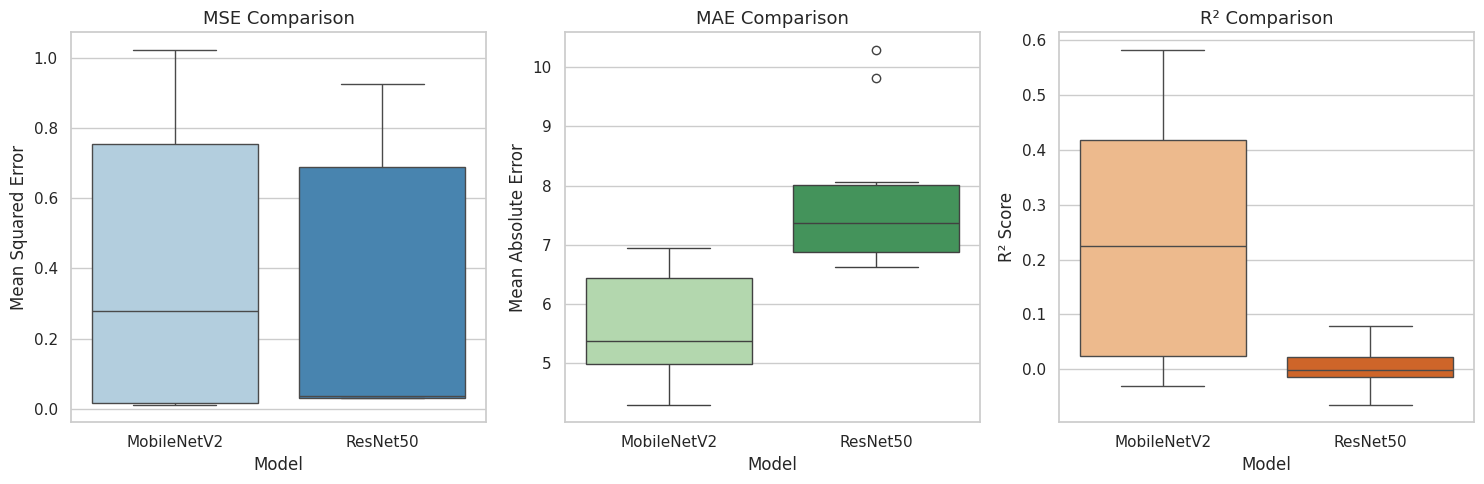

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your actual data
mse_model1 = [0.0160, 0.0119, 0.2771, 0.2944, 0.2811, 0.2908, 0.0169, 0.0198, 0.0165, 0.2428, 1.0232, 1.0035, 0.9079, 0.9069]  # MobileNetV2
mae_model1 = [4.48, 4.30, 5.10, 5.30, 5.17, 5.44, 5.66, 5.89, 4.94, 4.58, 6.95, 6.85, 6.61, 6.64]
r2_model1  = [0.0875, 0.0881, 0.4166, 0.3621, 0.5820, 0.4191, 0.4590, 0.4120, 0.0812, 0.5605, -0.0300, 0.006, -0.0055, -0.0156]

mse_model2 = [0.0490, 0.0431, 0.0389, 0.0313, 0.0298, 0.0322, 0.0333, 0.0319, 0.032, 0.0302, 0.9267, 0.9268, 0.9070, 0.9035]  # ResNet50
mae_model2 = [9.82, 10.29, 7.57, 7.39, 7.33, 6.99, 8.06, 7.99, 7.01, 8.01, 6.84, 6.84, 6.67, 6.63]
r2_model2  = [0.078847, -0.0499, -0.0642, 0.03868, 0.01243, 0.009546, -0.009671, -0.003622, -0.006759, -0.041012, 0.0261, 0.0263, -0.0166, 0.0004]

# Combine into a DataFrame
data = {
    'Model': ['MobileNetV2'] * 14 + ['ResNet50'] * 14,
    'MSE': mse_model1 + mse_model2,
    'MAE': mae_model1 + mae_model2,
    'R2': r2_model1 + r2_model2
}
df = pd.DataFrame(data)

# Set Seaborn style
sns.set(style="whitegrid")

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MSE Boxplot
sns.boxplot(x='Model', y='MSE', data=df, palette='Blues', ax=axes[0])
axes[0].set_title('MSE Comparison', fontsize=13)
axes[0].set_ylabel('Mean Squared Error')

# MAE Boxplot
sns.boxplot(x='Model', y='MAE', data=df, palette='Greens', ax=axes[1])
axes[1].set_title('MAE Comparison', fontsize=13)
axes[1].set_ylabel('Mean Absolute Error')

# R² Boxplot
sns.boxplot(x='Model', y='R2', data=df, palette='Oranges', ax=axes[2])
axes[2].set_title('R² Comparison', fontsize=13)
axes[2].set_ylabel('R² Score')

# Adjust layout
plt.tight_layout()
plt.show()


/tmp/ipython-input-382913572.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Accuracy', data=df, palette='Set2', width=0.5)


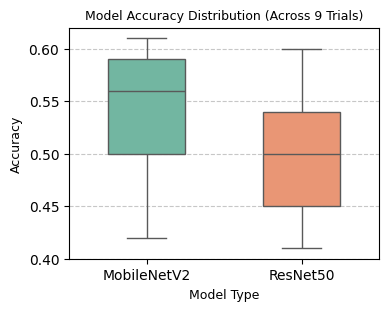

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example data: 2 models with 9 accuracy values each
data = {
    'Model': ['MobileNetV2'] * 9 + ['ResNet50'] * 9,
    'Accuracy': [
        0.59, 0.56, 0.56, 0.61, 0.60, 0.42, 0.53, 0.50, 0.50,  # MobileNetV2 accuracies
        0.41, 0.44, 0.45, 0.50, 0.52, 0.48, 0.60, 0.54, 0.58   # ResNet50 accuracies
    ]
}

df = pd.DataFrame(data)

# Create boxplot
plt.figure(figsize=(4, 3))
sns.boxplot(x='Model', y='Accuracy', data=df, palette='Set2', width=0.5)

# Add titles and labels
plt.title('Model Accuracy Distribution (Across 9 Trials)', fontsize=9)
plt.xlabel('Model Type', fontsize=9)
plt.ylabel('Accuracy', fontsize=9)

# Optional: Add gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()


In [ ]:
import pandas as pd
from scipy import stats

# Data setup
data = {
    'Model': ['MobileNetV2'] * 9 + ['ResNet50'] * 9,
    'Accuracy': [
        0.59, 0.56, 0.56, 0.61, 0.60, 0.42, 0.53, 0.50, 0.50,  # MobileNetV2
        0.41, 0.44, 0.45, 0.50, 0.52, 0.48, 0.60, 0.54, 0.58   # ResNet50
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Separate the accuracies for each model
mobilenet_acc = df[df['Model'] == 'MobileNetV2']['Accuracy']
resnet_acc = df[df['Model'] == 'ResNet50']['Accuracy']

# Perform independent t-test
t_stat, p_val = stats.ttest_ind(mobilenet_acc, resnet_acc, equal_var=False)

# Display results
print("Accuracy t-test Results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# Interpretation
alpha = 0.05
if p_val < alpha:
    print("→ There is a significant difference in accuracy between MobileNetV2 and ResNet50.")
else:
    print("→ There is no significant difference in accuracy between MobileNetV2 and ResNet50.")


Accuracy t-test Results:
T-statistic: 1.3205
P-value: 0.2053
→ There is no significant difference in accuracy between MobileNetV2 and ResNet50.


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# Data for MobileNetV2
mse_model1 = [0.0160, 0.0119, 0.2771, 0.2944, 0.2811, 0.2908, 0.0169, 0.0198, 0.0165, 0.2428, 1.0232, 1.0035, 0.9079, 0.9069]
mae_model1 = [4.48, 4.30, 5.10, 5.30, 5.17, 5.44, 5.66, 5.89, 4.94, 4.58, 6.95, 6.85, 6.61, 6.64]
r2_model1  = [0.0875, 0.0881, 0.4166, 0.3621, 0.5820, 0.4191, 0.4590, 0.4120, 0.0812, 0.5605, -0.0300, 0.006, -0.0055, -0.0156]

# Classification accuracy for MobileNetV2
acc_model1 = [0.59, 0.56, 0.56, 0.61, 0.60, 0.42, 0.53, 0.50, 0.50]

# Data for ResNet50
mse_model2 = [0.0490, 0.0431, 0.0389, 0.0313, 0.0298, 0.0322, 0.0333, 0.0319, 0.032, 0.0302, 0.9267, 0.9268, 0.9070, 0.9035]
mae_model2 = [9.82, 10.29, 7.57, 7.39, 7.33, 6.99, 8.06, 7.99, 7.01, 8.01, 6.84, 6.84, 6.67, 6.63]
r2_model2  = [0.078847, -0.0499, -0.0642, 0.03868, 0.01243, 0.009546, -0.009671, -0.003622, -0.006759, -0.041012, 0.0261, 0.0263, -0.0166, 0.0004]

# Classification accuracy for ResNet50
acc_model2 = [0.41, 0.44, 0.45, 0.50, 0.52, 0.48, 0.60, 0.54, 0.58]

# Perform t-tests
metrics = {
    "Accuracy": (acc_model1, acc_model2),
    "Mean Squared Error (MSE)": (mse_model1, mse_model2),
    "Mean Absolute Error (MAE)": (mae_model1, mae_model2),
    "R² Score": (r2_model1, r2_model2),
}

results = []

for name, (data1, data2) in metrics.items():
    t_stat, p_val = stats.ttest_ind(data1, data2, equal_var=False)
    significance = "Significant (p < 0.05)" if p_val < 0.05 else "Not Significant"
    results.append([name, np.mean(data1), np.mean(data2), t_stat, p_val, significance])

# Create DataFrame for table display
results_df = pd.DataFrame(results, columns=[
    "Metric", "MobileNetV2 Mean", "ResNet50 Mean", "T-Statistic", "P-Value", "Significance"
])

# Round for clean display
results_df["MobileNetV2 Mean"] = results_df["MobileNetV2 Mean"].round(4)
results_df["ResNet50 Mean"] = results_df["ResNet50 Mean"].round(4)
results_df["T-Statistic"] = results_df["T-Statistic"].round(4)
results_df["P-Value"] = results_df["P-Value"].round(4)

# Display results
print("T-Test Comparison Between MobileNetV2 and ResNet-50\n")
display(results_df)


T-Test Comparison Between MobileNetV2 and ResNet-50



,Metric,MobileNetV2 Mean,ResNet50 Mean,T-Statistic,P-Value,Significance
0,Accuracy,0.5411,0.5022,1.3205,0.2053,Not Significant
1,Mean Squared Error (MSE),0.3792,0.2868,0.6014,0.5528,Not Significant
2,Mean Absolute Error (MAE),5.5650,7.6743,-5.4818,0.0000,Significant (p < 0.05)
3,R² Score,0.2445,0.0000,3.8922,0.0017,Significant (p < 0.05)


In [ ]:
import numpy as np
from scipy.stats import ttest_ind

# Accuracy values for each model
mobilenetv2_acc = [0.59, 0.56, 0.56, 0.61, 0.60, 0.42, 0.53, 0.50, 0.50]
resnet50_acc = [0.41, 0.44, 0.45, 0.50, 0.52, 0.48, 0.60, 0.54, 0.58]

# Perform independent t-test
t_stat, p_val = ttest_ind(mobilenetv2_acc, resnet50_acc)

# Display results
print("=== T-Test for Accuracy Comparison ===")
print(f"MobileNetV2 Mean Accuracy: {np.mean(mobilenetv2_acc):.4f}")
print(f"ResNet50 Mean Accuracy:    {np.mean(resnet50_acc):.4f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_val:.4f}")

# Interpret significance
if p_val < 0.05:
    print("Result: Significant difference (p < 0.05)")
else:
    print("Result: Not significant (p ≥ 0.05)")


=== T-Test for Accuracy Comparison ===
MobileNetV2 Mean Accuracy: 0.5411
ResNet50 Mean Accuracy:    0.5022
T-Statistic: 1.3205
P-Value:     0.2052
Result: Not significant (p ≥ 0.05)
